In [1]:
# input
model_site_file = "./tmp/sampled_metal_binding_result.tsv"
pred_site_file = "../tmp/150_idp_mbp.tsv"
# output
plddt_delta_fig = "./fig/plddt_delta.pdf"


#### compare the match result of sample_0 in protenix

In [2]:
import pandas as pd

df_model = pd.read_table(model_site_file)
df_pred = pd.read_table(pred_site_file)
df_pred['pred_seq_num'] = df_pred['site'].map(lambda x: ",".join(sorted([str(int(i) + 1) for i in x.split(",")])))

records = []
for (pdb, ), df_pdb in df_model.groupby(['pdb']):
    df_pdb_ched = df_pdb[df_pdb['resi'].map(lambda x: x in {"Cys", "His", "Asp", "Glu"})]
    seq_nums = df_pdb_ched['resi_ndb_seq_can_num'].drop_duplicates().tolist()
    seq_nums.sort()
    records.append({
        "seq_id": pdb,
        "protenix_seq_num": ",".join([str(i) for i in seq_nums])
    })

# from "../../../../af3/analysis/coverage.ipynb"
def is_pro_matched(row: dict):
    pred_nums = set([i for i in row['pred_seq_num'].split(",")])
    model_nums = set([i for i in row['protenix_seq_num'].split(",")])
    inter = pred_nums & model_nums
    return 1 if len(inter) > 0 else 0

df = pd.merge(df_pred, pd.DataFrame(records), on="seq_id")
df['pro_matched'] = df.apply(lambda row: is_pro_matched(row), axis=1)
df['pro_matched'].sum()
df['pro_matched'].sum() / len(df)

np.int64(145)

np.float64(0.9666666666666667)

In [3]:
df[df['pro_matched'] == 0]

,seq_id,site,plddt,proba,pred_seq_num,protenix_seq_num,pro_matched
64,A0A7J6LJS8,"569,572,577,582","26.89,28.3,37.63,42.73","0.9207,0.8738,0.9617,0.9232","570,573,578,583","75,78,84,466",0
104,A9SQ04,"326,329,333,338","31.31,40.93,35.56,33.29","0.8806,0.8732,0.9266,0.8582","327,330,334,339","304,307,312,317",0
120,A0A0V0QWV1,"191,194,209,212","40.94,39.52,35.54,36.96","0.9541,0.9302,0.8918,0.8848","192,195,210,213","594,597,613,616",0
144,A0A388KEY2,"887,890,895","30.43,31.26,34.85","0.8941,0.9592,0.9561","888,891,896","315,320,322,325",0
146,D7FSF5,"267,275,278","43.01,43.01,47.25","0.9764,0.9369,0.9156","268,276,279","20,31,37,39,183",0


#### calc plddt change in sample_0 in protenix

In [4]:
from Bio.PDB.MMCIFParser import MMCIFParser
import os
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB.Structure import Structure
from Bio.PDB.Model import Model
from Bio.PDB.Residue import Residue
from Bio.PDB.Chain import Chain

def get_num_to_residues(
    id: str,
    file: str
) -> dict:
    def parse_mmcif_file(
        id: str,
        file: str,
    ) -> tuple[Structure, MMCIF2Dict]:

        file = os.path.expanduser(file)
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(id, file)
        mmcif_dict = parser._mmcif_dict
        return structure, mmcif_dict

    def get_target_chain(
        model: Model,
        chain_id: str,
    ) -> Chain:

        target_chain: Chain = None
        for c in model.get_chains():
            c: Chain
            if c.get_id() == chain_id:
                target_chain = c
                break
        return target_chain
    
    struct, _ = parse_mmcif_file(id, file)
    chain = get_target_chain(next(struct.get_models()), "A")
    assert chain is not None

    result = dict()
    for c in chain.get_residues():
        result[c.get_full_id()[3][1]] = c
    return result


def get_plddt_info(
    residues: dict[int, Residue],
    target_nums: list[int]
):
    avg_plddt = sum([r['CA'].get_bfactor() for r in residues.values()]) / len(residues)
    target_plddts = [residues[i]['CA'].get_bfactor() for i in target_nums]
    return avg_plddt, target_plddts

In [5]:
import numpy as np

records = []
for _, row in df.iterrows():
    seq_id = row['seq_id']
    model_file = f"../tmp/pred_struct/{seq_id}/seed_42/predictions/{seq_id}_sample_0.cif"
    model_with_metal_file = f"../tmp/pred_struct_with_metal/{seq_id}/seed_42/predictions/{seq_id}_sample_0.cif"

    pred_nums = [int(i) for i in row['pred_seq_num'].split(',')]
    
    model_result = get_plddt_info(
        get_num_to_residues(seq_id, model_file),
        pred_nums
    )
    model_with_metal_result = get_plddt_info(
        get_num_to_residues(seq_id, model_with_metal_file),
        pred_nums
    )
    
    records.append({
        "seq_id": seq_id,
        "avg_plddt": model_result[0],
        "plddt": model_result[1],
        "with_metal_avg_plddt": model_with_metal_result[0],
        "with_metal_plddt": model_with_metal_result[1],
        "pro_plddt_delta": model_with_metal_result[0] - model_result[0],
        "site_plddt_delta": sum(model_with_metal_result[1]) / len(model_with_metal_result[1]) - sum(model_result[1]) / len(model_result[1]),
        "site_plddt_proteinx_af2_delta": sum(model_result[1]) / len(model_result[1]) - np.mean([float(i) for i in row['plddt'].split(",")])
    })

In [6]:
df_result = pd.merge(df.rename(columns={'plddt': "af2_plddt"}), pd.DataFrame(records), on='seq_id')

In [7]:
df_result

,seq_id,site,af2_plddt,proba,pred_seq_num,protenix_seq_num,pro_matched,avg_plddt,plddt,with_metal_avg_plddt,with_metal_plddt,pro_plddt_delta,site_plddt_delta,site_plddt_proteinx_af2_delta
0,K5XPP2,"480,483,488","44.74,38.56,37.15","0.9899,0.9815,0.9399","481,484,489","251,252,481,484,486",1,47.518007,"[43.31, 43.57, 33.92]",41.708043,"[45.0, 50.01, 32.35]",-5.809964,2.186667,0.116667
1,A0A6A3HSH8,"24,27,32,37","49.54,47.88,41.54,46.23","0.9361,0.9607,0.8607,0.938","25,28,33,38","25,28,33,38",1,58.435037,"[63.84, 70.43, 68.27, 70.24]",56.134688,"[59.96, 68.9, 64.73, 67.66]",-2.300349,-2.882500,21.897500
2,A0A7G1PCE0,"313,316,323","42.13,47.43,42.41","0.9496,0.8916,0.8925","314,317,324","310,311,314,317,324",1,54.326875,"[49.52, 47.0, 39.17]",54.337525,"[46.72, 42.19, 39.81]",0.010650,-2.323333,1.240000
3,A0A2W2DWW6,"179,183,191,195","35.92,42.82,43.03,38.94","0.9799,0.9845,0.9243,0.9746","180,184,192,196","180,184,192,196",1,43.507000,"[43.52, 41.02, 41.84, 43.94]",61.001160,"[53.64, 58.02, 53.66, 52.43]",17.494160,11.857500,2.402500
4,G1QBZ9,"318,328,331","39.14,28.1,28.95","0.9561,0.8364,0.8627","319,329,332","316,319,329,332,346",1,70.187881,"[54.36, 56.04, 53.65]",68.346305,"[52.62, 52.27, 51.99]",-1.841576,-2.390000,22.620000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,A0A2H1W2L1,"39,42,91,94","44.79,39.2,42.99,43.53","0.9731,0.923,0.9747,0.9564","40,43,92,95","40,43,92,95",1,71.385321,"[90.99, 92.97, 92.83, 92.81]",73.499541,"[93.1, 95.32, 95.14, 95.47]",2.114220,2.357500,49.772500
146,D7FSF5,"267,275,278","43.01,43.01,47.25","0.9764,0.9369,0.9156","268,276,279","20,31,37,39,183",0,59.394876,"[59.47, 57.67, 54.05]",58.881405,"[60.87, 58.09, 53.96]",-0.513471,0.576667,12.640000
147,A0A554SP07,"23,45,48","30.34,32.74,36.66","0.9893,0.9933,0.9459","24,46,49","19,24,46,49",1,45.884881,"[45.91, 45.68, 48.76]",51.971786,"[59.09, 57.3, 58.35]",6.086905,11.463333,13.536667
148,A0A6P6DE34,"70,90,93","38.63,46.07,46.64","0.8778,0.9778,0.9954","71,91,94","55,56,91,94,126",1,40.234264,"[41.42, 53.44, 56.48]",42.540620,"[41.21, 55.53, 55.66]",2.306357,0.353333,6.666667


<Figure size 240x240 with 0 Axes>

/tmp/ipykernel_3881136/1842534170.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_bin, labels=bin_labels, showfliers=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x7526f8044890>,
 'caps': [<matplotlib.lines.Line2D at 0x7526f8d5a5d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7526f8046c90>,
 'medians': [<matplotlib.lines.Line2D at 0x7526f8d58190>,
 'fliers': [],
 'means': []}

Text(0, 0.5, 'Averge pLDDT change')

(array([1, 2, 3]),
 [Text(1, 0, 'Protein: w/ vs w/o metal'),
  Text(2, 0, 'Site: w/ vs w/o metal'),
  Text(3, 0, 'Site (w/o metal): protenix vs af2')])

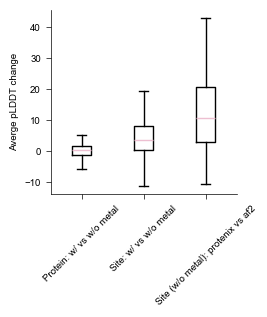

In [8]:
import matplotlib.pyplot as plt
plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

data_per_bin = [
    df_result['pro_plddt_delta'].tolist(),
    df_result['site_plddt_delta'].tolist(),
    df_result['site_plddt_proteinx_af2_delta'].tolist()
]
bin_labels = ['Protein: w/ vs w/o metal', 'Site: w/ vs w/o metal', "Site (w/o metal): protenix vs af2"]

plt.figure(figsize=(2.4, 2.4))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.boxplot(data_per_bin, labels=bin_labels, showfliers=False)
plt.ylabel('Averge pLDDT change')
plt.xticks(rotation=45)
plt.savefig(plddt_delta_fig, bbox_inches="tight", transparent=True)